## Tennis Versus (02 - restructuring the data and removing some unneeded features)

We have saved our work from ```01_data_exploration.ipynb``` into ```cleaned_matches_01done.parquet```.

We can now use our DataFrame from 01 here. We will now restructure the data so it will actually be useful with our model.

In [13]:
# data analytics + math
import pandas as pd 
import numpy as np 

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# other stuff used for later (need sci-kit learn too)
import xgboost # just installed it using !pip install

# set some parameters for pandas to view the data a bit better
pd.set_option('display.max_columns', 50) # see ALL columns
pd.set_option('display.width', 150)

df = pd.read_parquet('parquets/cleaned_matches_01done.parquet')

### renaming + deleting columns

there's a lot of columns in this DataFrame. Some seem more useful than others.

for example, ```tourney_id``` and player id are just identifiers - not useful for our model.
```winner_seed``` ```winner_entry``` is also not that important.

Most importantly, our dataset inherently labels the winner using the column names already. 
We want to separate this so our model doesn't take that into account.

What we want is more of a ```player_a``` and ```player_b``` and a ```label``` column signifying who won. 

In our case, ```label``` will basically be asking: "Did player A win?". ```1``` if player A wins, and ```0``` if player A loses (or player B wins).

#### important side note

ok, so we will rename ```winner_name``` --> ```player_a``` and ```loser_name``` --> ```player_b```. <br>
Then, ```label``` will be all ```1``` because we have constructed it so that player A is the winner.

Our model will simply always predict ```1``` because that's all there is.

Thus, we also need to add a "flipped" direction. In addition to what we did above, we will also add: <br>
```loser_name``` --> ```player_a``` and ```winner_name``` --> ```player_b```. Then ```label``` will be  ```0``` because player A didn't win.

Now, the model will actually have 0s and 1s to work with and figure out which features are most important and correlate the most.

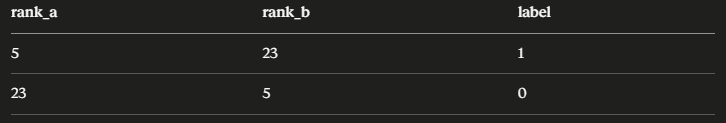

is much more useful than

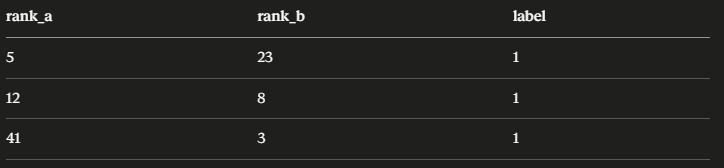

because there is now actually a way for our model to predict our label to be 0 or 1.